# Edge Detection & Morphological Operations
## Computer Vision Practice - Week 2, Day 3 (Wednesday)

**Objective:** Master edge detection algorithms and morphological image processing techniques.

**Topics:**
- Edge detection algorithms (Sobel, Canny, Laplacian, Prewitt)
- Image gradient and directional derivatives
- Morphological operations (Erosion, Dilation, Opening, Closing)
- Structural elements (kernels)
- Practical applications and demos

## 1. Libraries & Setup

## 1. Libraries & Setup

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


## 2. Edge Detection Algorithms

**What is edge detection?**
Edge detection identifies boundaries in an image where intensity changes sharply. Edges are important for:
- Object recognition and localization
- Image segmentation
- Feature extraction for computer vision tasks

### Types of Edge Detectors:
- **Sobel:** Uses X and Y derivatives to find edges with directional information
- **Canny:** Multi-stage algorithm that produces thin, connected edges (best quality)
- **Laplacian:** Second derivative operator, very sensitive to noise
- **Prewitt:** Similar to Sobel, slightly different kernel values

### How they work:
All edge detectors use convolution with kernels (small matrices) to compute image gradients. The gradient magnitude indicates the strength of the edge.

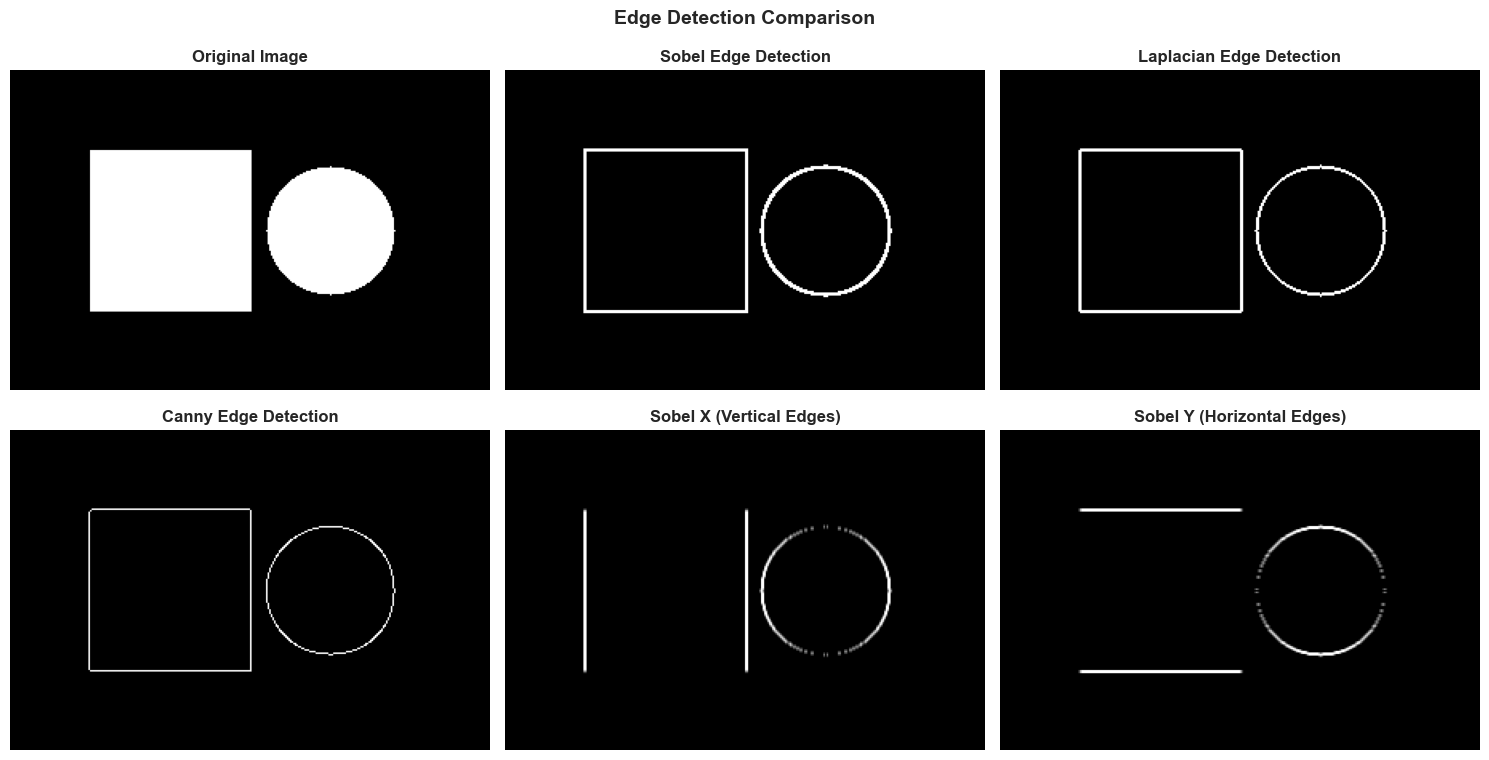

✓ Edge detection complete!

=== EDGE DETECTOR COMPARISON ===
Sobel:      Fast, shows magnitude and direction
Canny:      Best quality, thin connected edges, two-stage thresholding
Laplacian:  Sensitive, shows zero-crossings, prone to noise
Prewitt:    Similar to Sobel, slightly different kernel weights


In [3]:
# --- MORNING SESSION: Edge Detection Algorithms ---

# Create a simple test image with geometric shapes
test_img = np.zeros((200, 300, 3), dtype=np.uint8)
cv2.rectangle(test_img, (50, 50), (150, 150), (255, 255, 255), -1)  # White rectangle
cv2.circle(test_img, (200, 100), 40, (255, 255, 255), -1)  # White circle
test_gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)

# Apply different edge detectors
sobel_x = cv2.Sobel(test_gray, cv2.CV_64F, 1, 0, ksize=3)  # X derivative (vertical edges)
sobel_y = cv2.Sobel(test_gray, cv2.CV_64F, 0, 1, ksize=3)  # Y derivative (horizontal edges)
sobel = np.sqrt(sobel_x**2 + sobel_y**2)  # Magnitude of gradient

laplacian = cv2.Laplacian(test_gray, cv2.CV_64F)  # Second derivative
canny = cv2.Canny(test_gray, 50, 150)  # Canny with threshold1=50, threshold2=150
prewitt_x = cv2.Sobel(test_gray, cv2.CV_64F, 1, 0, ksize=3)  # Prewitt-like (similar to Sobel)

# Normalize for display (convert to 0-255 range)
sobel = np.uint8(np.clip(sobel, 0, 255))
laplacian = np.uint8(np.clip(np.abs(laplacian), 0, 255))

# Visualize all edge detectors
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(test_gray, cmap='gray')
axes[0, 0].set_title('Original Image', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(sobel, cmap='gray')
axes[0, 1].set_title('Sobel Edge Detection', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(laplacian, cmap='gray')
axes[0, 2].set_title('Laplacian Edge Detection', fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(canny, cmap='gray')
axes[1, 0].set_title('Canny Edge Detection', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(np.abs(sobel_x), cmap='gray')
axes[1, 1].set_title('Sobel X (Vertical Edges)', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(np.abs(sobel_y), cmap='gray')
axes[1, 2].set_title('Sobel Y (Horizontal Edges)', fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Edge Detection Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Edge detection complete!")
print("\n=== EDGE DETECTOR COMPARISON ===")
print("Sobel:      Fast, shows magnitude and direction")
print("Canny:      Best quality, thin connected edges, two-stage thresholding")
print("Laplacian:  Sensitive, shows zero-crossings, prone to noise")
print("Prewitt:    Similar to Sobel, slightly different kernel weights")

## 3. Morphological Operations

**What is morphology?**
Morphological operations process binary images based on shape. They use a structural element (small kernel) to modify the image structure.

### Key Operations:

**Erosion:** Removes white pixels from edges
- Effect: Shrinks white regions, removes small objects
- Use case: Cleaning noise, separating objects

**Dilation:** Adds white pixels to edges  
- Effect: Grows white regions, fills holes
- Use case: Connecting broken regions, thickening lines

**Opening:** Erosion followed by Dilation
- Effect: Removes small objects but preserves overall shape
- Use case: Noise removal without affecting large objects

**Closing:** Dilation followed by Erosion
- Effect: Fills holes inside objects but preserves outer shape
- Use case: Filling gaps and holes

**Gradient (Morphological):** Dilation minus Erosion
- Effect: Extracts the boundary/outline
- Use case: Edge detection on binary images

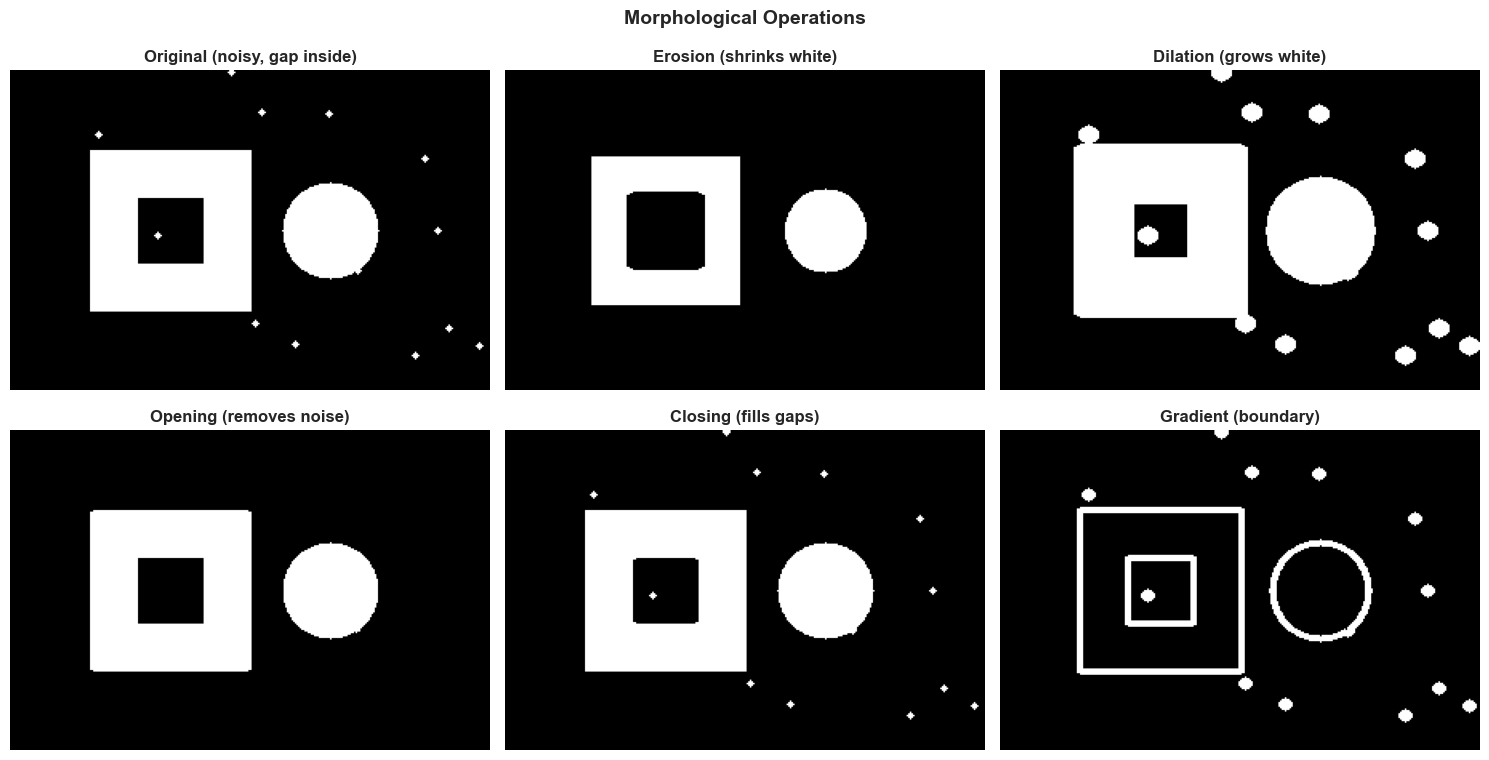

✓ Morphological operations complete!

=== MORPHOLOGICAL OPERATIONS SUMMARY ===
Opening:   Erosion → Dilation   | Removes noise, keeps large objects
Closing:   Dilation → Erosion   | Fills holes, keeps main objects
Gradient:  Dilation - Erosion   | Extracts object boundaries

Best practices:
- Opening: Use for noise removal in binary images
- Closing: Use for filling gaps and holes in objects
- Gradient: Use for edge detection on binary/binary-like images


In [4]:
# --- AFTERNOON SESSION: Morphological Operations ---

# Create binary image with noise and gaps
morph_img = np.zeros((200, 300), dtype=np.uint8)
cv2.rectangle(morph_img, (50, 50), (150, 150), 255, -1)  # Large rectangle
cv2.circle(morph_img, (200, 100), 30, 255, -1)  # Circle
# Add a hole (gap) inside the rectangle
cv2.rectangle(morph_img, (80, 80), (120, 120), 0, -1)
# Add noise (small random white pixels)
noise_points = np.random.randint(0, 300, (20, 2))
for pt in noise_points:
    cv2.circle(morph_img, tuple(pt), 2, 255, -1)

# Define structural element (kernel)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Apply morphological operations
erosion = cv2.erode(morph_img, kernel, iterations=2)
dilation = cv2.dilate(morph_img, kernel, iterations=2)
opening = cv2.morphologyEx(morph_img, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(morph_img, cv2.MORPH_CLOSE, kernel)
gradient = cv2.morphologyEx(morph_img, cv2.MORPH_GRADIENT, kernel)

# Visualize morphological operations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(morph_img, cmap='gray')
axes[0, 0].set_title('Original (noisy, gap inside)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(erosion, cmap='gray')
axes[0, 1].set_title('Erosion (shrinks white)', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(dilation, cmap='gray')
axes[0, 2].set_title('Dilation (grows white)', fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(opening, cmap='gray')
axes[1, 0].set_title('Opening (removes noise)', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(closing, cmap='gray')
axes[1, 1].set_title('Closing (fills gaps)', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(gradient, cmap='gray')
axes[1, 2].set_title('Gradient (boundary)', fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Morphological Operations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Morphological operations complete!")
print("\n=== MORPHOLOGICAL OPERATIONS SUMMARY ===")
print("Opening:   Erosion → Dilation   | Removes noise, keeps large objects")
print("Closing:   Dilation → Erosion   | Fills holes, keeps main objects")
print("Gradient:  Dilation - Erosion   | Extracts object boundaries")
print("\nBest practices:")
print("- Opening: Use for noise removal in binary images")
print("- Closing: Use for filling gaps and holes in objects")
print("- Gradient: Use for edge detection on binary/binary-like images")

## 4. Summary & Applications

### Key Takeaways:

1. **Edge Detection** finds intensity boundaries in images
   - Sobel/Prewitt: Good for general edge detection
   - Canny: Best quality edges, recommended for most tasks
   - Laplacian: Sensitive but useful for certain applications

2. **Morphological Operations** modify binary image structure
   - Opening/Closing: Clean and fill binary images
   - Gradient: Extract object boundaries

3. **When to use each:**
   - Use edge detection → object detection, segmentation, feature extraction
   - Use morphology → cleaning binary masks, separating connected objects, filling holes

4. **Practical workflow:**
   - Detect edges → Threshold → Morphological operations → Object analysis